### 1) Bagging(Bootstrap Agregation)
- it takes dataset and creates random sample with replacement i fyou have 100 data 
- tree1 ==> 1,5,10,50
- tree2 ==> 2,9,15,80
### 2) feature Randomness

In [35]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [36]:
df.fillna(df["Age"].mean(),inplace=True)
df.replace({"female":0,"male":1}, inplace=True)
x=df[['Pclass','Sex', 'Age', 'SibSp',
       'Parch', 'Fare']]
y=df["Survived"]

print(x.shape)
y.shape

(891, 6)


C:\Users\LJENG\AppData\Local\Temp\ipykernel_6708\280803671.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"female":0,"male":1}, inplace=True)


(891,)

In [37]:
# from sklearn.model_selection import train_test_split
# x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.2)
# print(x_train.shape)
# print(y_train.shape)
# print(x_test.shape)
# print(y_test.shape)

In [38]:
# from sklearn.tree import DecisionTreeClassifier
# dtree=DecisionTreeClassifier(criterion="entropy") # default="gini"
# model=dtree.fit(x_train,y_train)
# pred=model.predict(x_test)

In [322]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,criterion="entropy") # random state apvu pade baki accuracy halse 😶🙄
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print(y_pred)

[1 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 1 1 1 1 0 0 0 1
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1
 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 0 1]


In [323]:
diff =pd.DataFrame({"Actual":y_test,"pred":y_pred})
diff

,Actual,pred
862,1,1
223,0,0
84,1,1
680,0,0
535,1,1
...,...,...
796,1,1
815,0,0
629,0,0
421,0,0


In [324]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.770949720670391


In [325]:
sample=x_test.iloc[0:1]
print(sample)
predction=rf.predict(sample)
predction

     Pclass  Sex   Age  SibSp  Parch     Fare
862       1    0  48.0      0      0  25.9292


array([1])

In [326]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"Pasenger data : {sample_dict}")
print(f"Pasenger survive :{'Survived' if predction[0]==1 else 'Not survived'}")

{'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
Pasenger data : {'Pclass': 1.0, 'Sex': 0.0, 'Age': 48.0, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 25.9292}
Pasenger survive :Survived


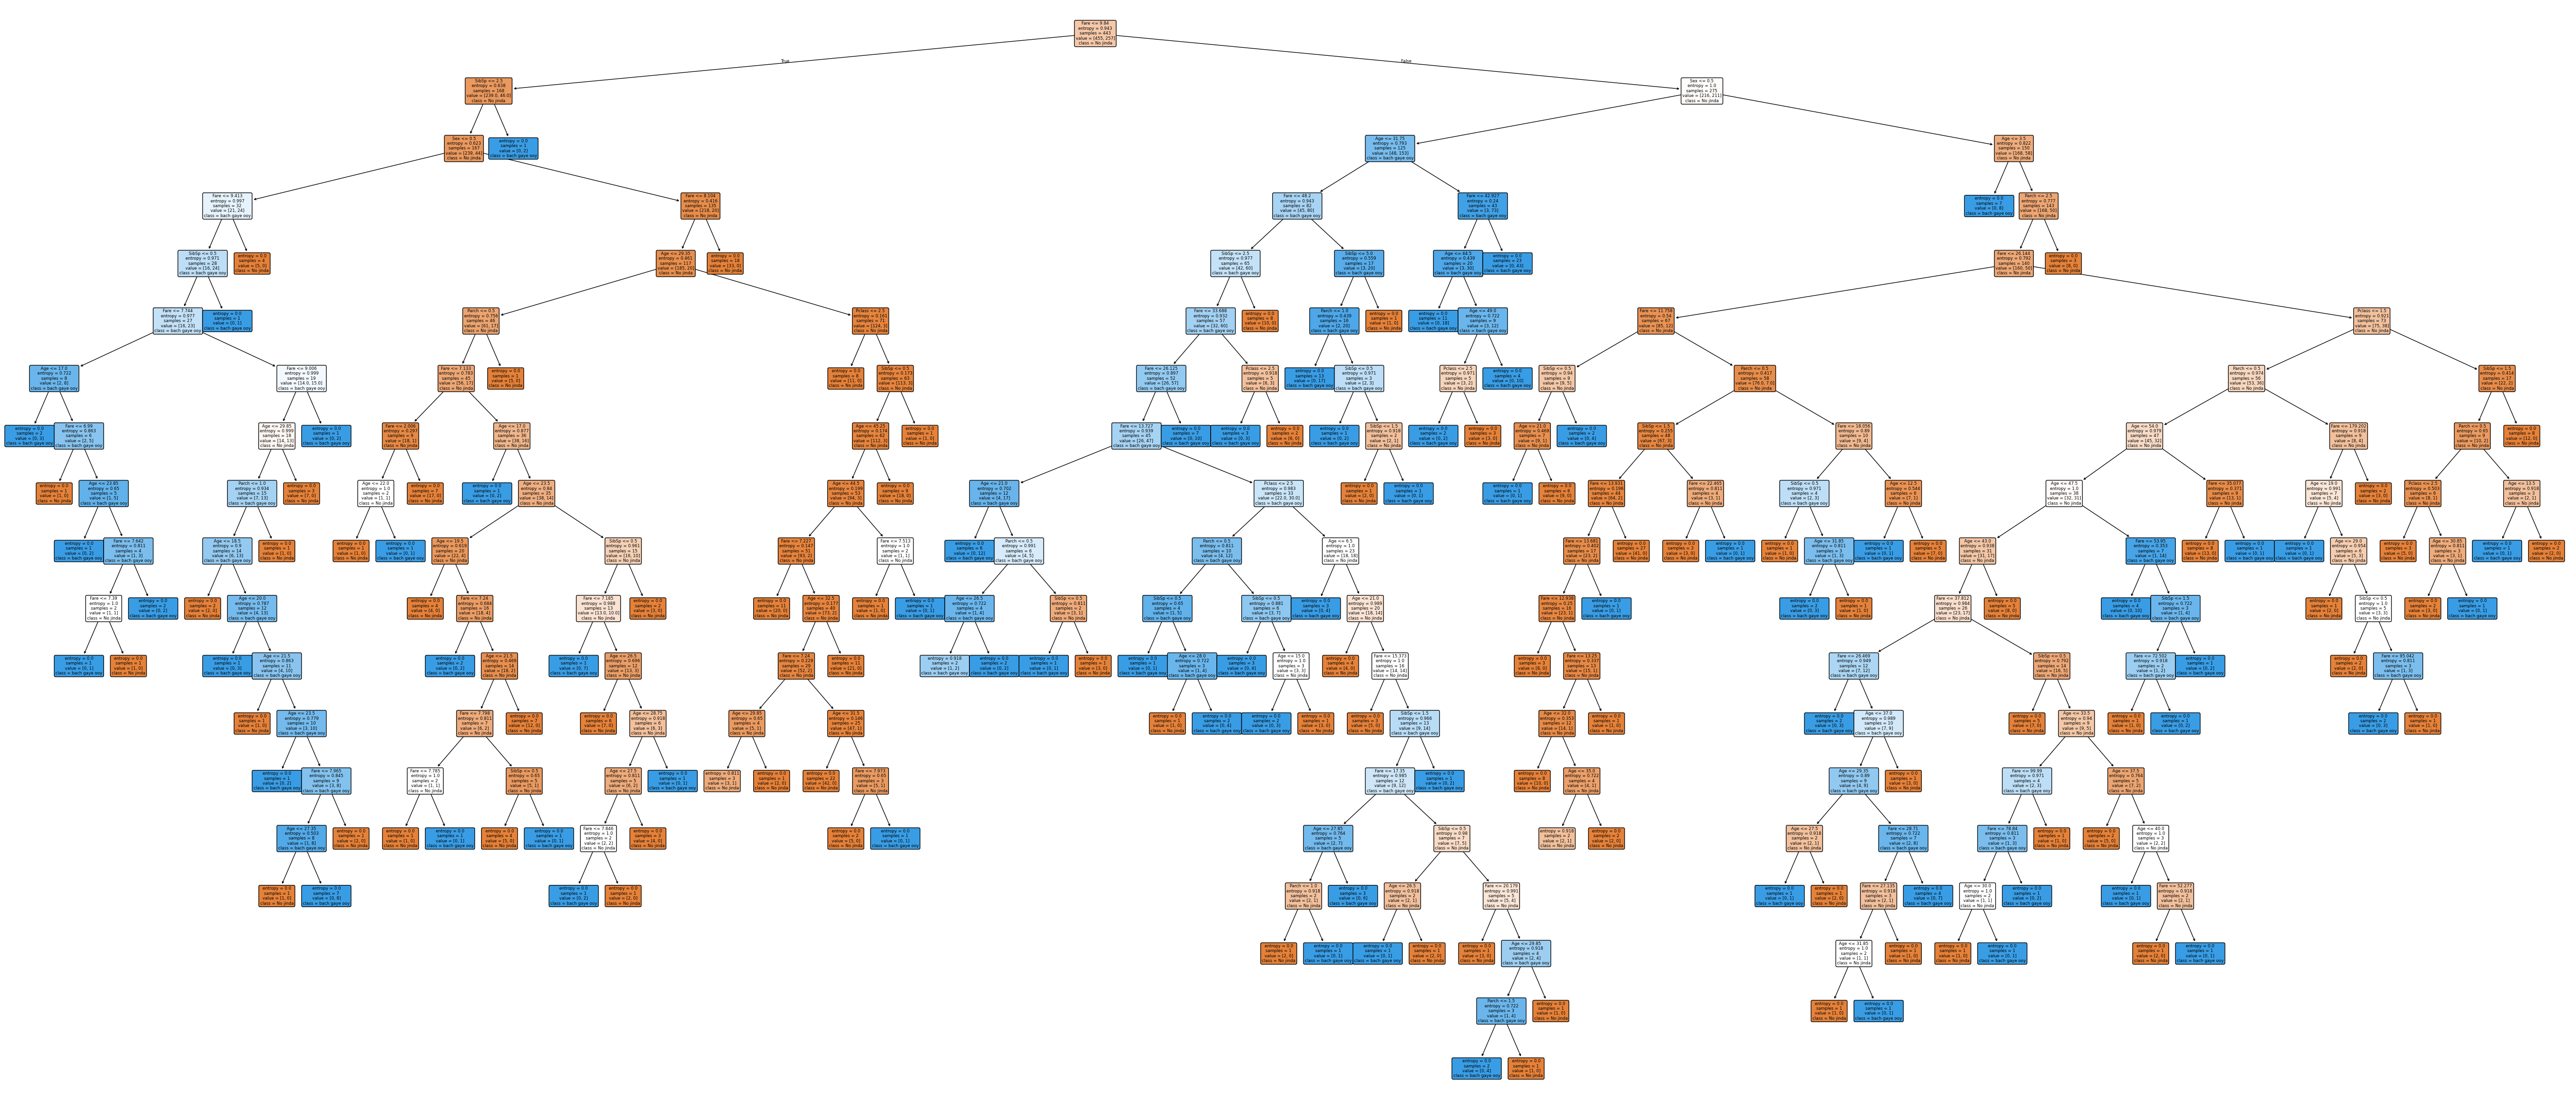

In [327]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf.estimators_[0]
plt.figure(figsize=(70,30))
plot_tree(chosen_tree,feature_names=x.columns,class_names=["No jinda","bach gaye ooy"],filled=True,rounded=True)
plt.show()

In [330]:
import pandas as pd
df=pd.read_csv("example.csv")
df

,Weight,Texture,Color,Fruit
0,150,smooth,red,apple
1,170,rough,orange,Orange
2,140,smooth,green,apple
3,180,rough,orange,Orange
4,160,smooth,red,apple
5,155,rough,yellow,Orange


In [341]:
df.replace({"smooth": 0, "rough": 1, "red": 0 ,"orange":1,"green":2,"yellow":3}, inplace=True)
df

,Weight,Texture,Color,Fruit
0,150,0,0,apple
1,170,1,1,Orange
2,140,0,2,apple
3,180,1,1,Orange
4,160,0,0,apple
5,155,1,3,Orange


In [342]:
x=df.drop(columns=["Fruit"])
y=df["Fruit"]
print(x.shape)
y.shape

(6, 3)


(6,)

In [343]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=42) # random state apvu pade baki accuracy halse 😶🙄
rf.fit(x,y)
y_pred=rf.predict(x)
print(y_pred)

['apple' 'Orange' 'apple' 'Orange' 'apple' 'Orange']


In [344]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y,y_pred))

1.0


In [345]:
sample=x.iloc[0:1]
print(sample)
predction=rf.predict(sample)
predction

   Weight  Texture  Color
0     150        0      0


array(['apple'], dtype=object)

In [346]:
sample_dict=sample.iloc[0].to_dict()
print(sample_dict)
print(f"Pasenger data : {sample_dict}")
print(f"Pasenger survive :{'a' if predction[0]==1 else 'b'}")

{'Weight': 150, 'Texture': 0, 'Color': 0}
Pasenger data : {'Weight': 150, 'Texture': 0, 'Color': 0}
Pasenger survive :b


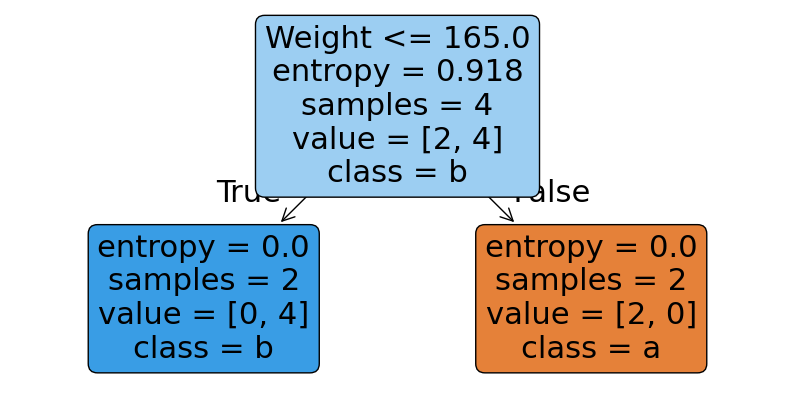

In [349]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
chosen_tree=rf.estimators_[0]
plt.figure(figsize=(10,5))
plot_tree(chosen_tree,feature_names=x.columns,class_names=["a","b"],filled=True,rounded=True)
plt.show()

# support Vector Machine 

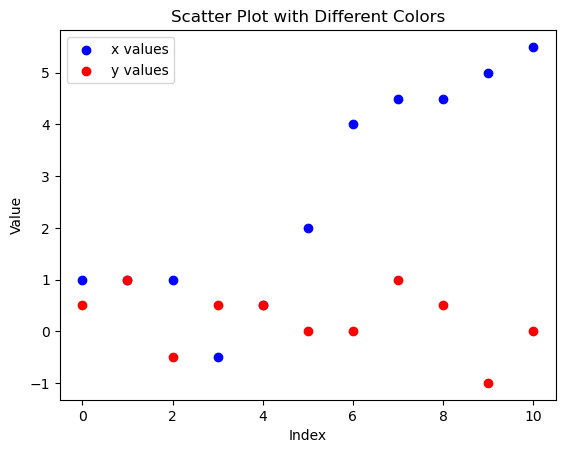

In [353]:
import matplotlib.pyplot as plt

x = [1, 1, 1, -0.5, 0.5, 2, 4, 4.5, 4.5, 5, 5.5]
y = [0.5, 1, -0.5, 0.5, 0.5, 0, 0, 1, 0.5, -1, 0]

plt.scatter(range(len(x)), x, color='blue', label='x values')
plt.scatter(range(len(y)), y, color='red', label='y values')

# Add labels and legend for clarity
plt.title("Scatter Plot with Different Colors")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()

plt.show()


In [355]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [357]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [359]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.2)  # random state apvu pade baki accuracy halse 
print(x_train.shape) #                                                              😶🙄 for decision tree
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(614, 8)
(614,)
(154, 8)
(154,)


In [362]:
from sklearn.svm import SVC
svc_classifier=SVC(kernel="rbf",C=1.0,random_state=1) # rbf=radial basic function , C regularization control the trade  
svc_classifier.fit(x_train,y_train)
predection=svc_classifier.predict(x_test)
print(predection)
diff =pd.DataFrame({"Actual":y_test,"pred":predection})
diff

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


,Actual,pred
285,0,0
101,0,1
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0
